<img src="../logo_UNSAM.jpg" align="right" width="150" /> 

# Análisis y Procesamiento de Señales
## Trabajo Semanal Nº 5: Ancho de banda de señales reales
**Autor:** Federico Pieri  
**Institución:** Escuela de Ciencia y Tecnología — Universidad Nacional de San Martín (UNSAM)

---

## Introducción

En este trabajo se estima el **ancho de banda** de señales reales de distinta naturaleza: un electrocardiograma (ECG), una señal de fotopletismografía (PPG) y tres registros de audio. Para ello se calcula la **densidad espectral de potencia (PSD)** de cada señal con el método de Welch y, a partir de ella, se determina el rango de frecuencias donde se concentra la potencia.

**Método de Welch.** La señal se divide en segmentos de longitud `nperseg`, con un solapamiento del 50 %. A cada segmento se le aplica una ventana (Hann, por defecto en `scipy`), se calcula su periodograma y finalmente se promedian todos. El parámetro `nperseg` define un compromiso entre resolución y varianza:

- **Segmentos largos:** mayor resolución en frecuencia ($\Delta f = f_s / nperseg$), pero una PSD más ruidosa (mayor varianza).
- **Segmentos cortos:** PSD más suave (menor varianza), pero con peor resolución y picos más anchos.

**Criterio de ancho de banda.** Se adopta el criterio del 98 % de la potencia total:

- En el **ECG** y la **PPG**, el ancho de banda se mide desde continua (0 Hz) hasta la frecuencia por debajo de la cual se acumula el 98 % de la potencia.
- En las señales de **audio**, se busca la banda $[f_{min}, f_{max}]$ que contiene el 98 % central de la potencia, descartando el 1 % de cada extremo del espectro. El ancho de banda es $BW = f_{max} - f_{min}$.

Las frecuencias de muestreo empleadas son $f_s = 1000$ Hz para el ECG, $f_s = 400$ Hz para la PPG y la propia de cada archivo `.wav` para el audio.

---

## 1. Estimaciones espectrales

En esta sección se calcula la PSD de cada señal mediante el método de Welch. Para el ECG y la PPG se comparan cuatro longitudes de segmento ($N/6$, $N/12$, $N/30$ y $N/37.5$, siendo $N$ la cantidad de muestras) con un solapamiento del 50 %, de modo de evaluar cómo influye este parámetro tanto en el aspecto de la PSD como en el ancho de banda estimado. Para el audio se utiliza una única longitud de segmento de $N/9$.

### Estimación espectral de la señal de ECG

Se analiza un registro de ECG, sin ruido, muestreado a 1000 Hz. Se grafica la PSD en el rango de 0 a 40 Hz, ya que por encima de esa frecuencia la potencia es prácticamente nula. La línea roja punteada marca la frecuencia por debajo de la cual se acumula el 98 % de la potencia, es decir, el ancho de banda estimado.

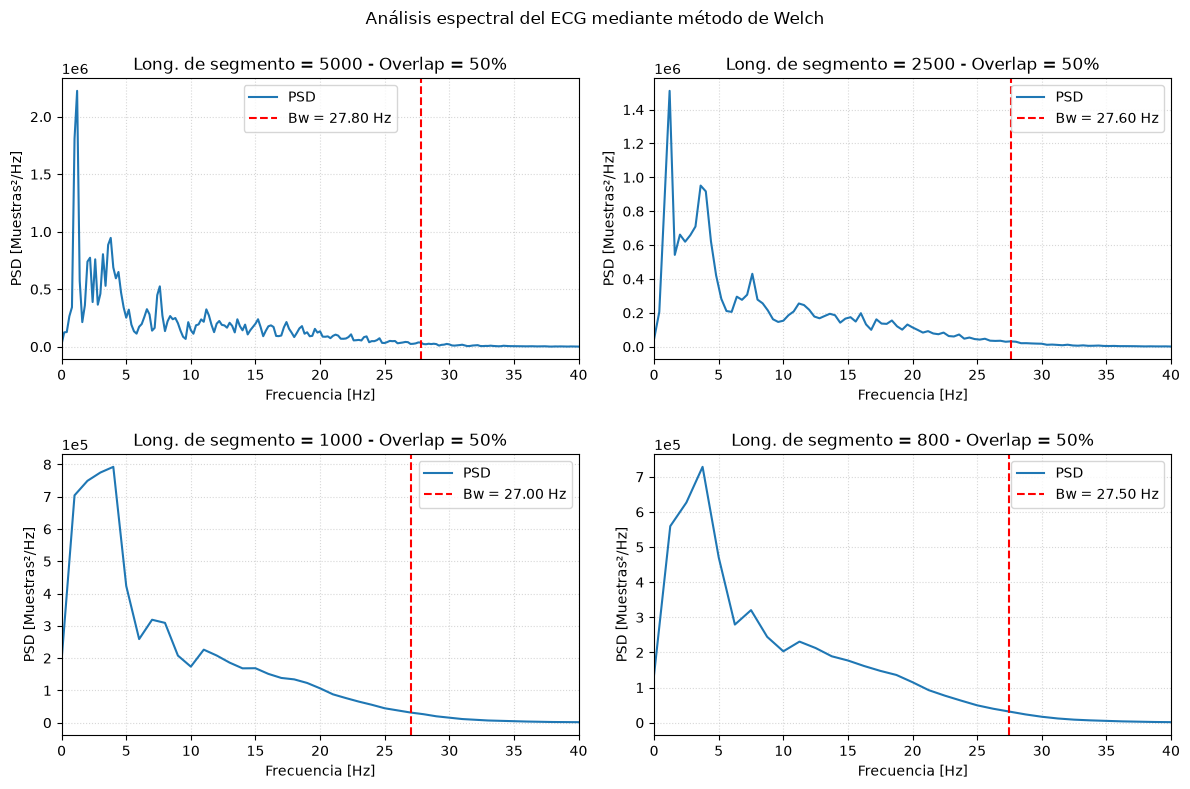

In [13]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
# import scipy.io as sio
# from scipy.io.wavfile import write

#%% --------------------------------- Definiciones
fs_ecg = 1000 # Hz
resultados_bw = {}

#%% ------------------------- Programa

ecg_one_lead = np.load('ecg_sin_ruido.npy')
len_ecg = len(ecg_one_lead)
combinaciones = [
    (len_ecg//6),
    (len_ecg//12),
    (len_ecg//30),
    (len_ecg//37.5)
]

plt.close()

#%% ------------------------------ Ploteos PSD

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, (nperseg) in zip(axs.ravel(), combinaciones):

    f_ecg, psd_ecg = sig.welch(
        ecg_one_lead,
        fs=fs_ecg,
        nperseg=nperseg,
        noverlap=nperseg//2,
        detrend='linear'
    )
    bw = gen.bw(f_ecg,psd_ecg,0.98) 
    if nperseg == combinaciones[1]:
        resultados_bw['ecg'] = {'f_min': 0,'f_max': bw,'BW': bw}
    ax.plot(f_ecg, psd_ecg , label='PSD')
    ax.axvline(x=bw, linestyle='--', color='red', label = f'Bw = {bw:.2f} Hz')
    ax.set_title(f'Long. de segmento = {nperseg:.0f} - Overlap = 50%')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD [Muestras²/Hz]')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlim(0, 40)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend()

plt.suptitle('Análisis espectral del ECG mediante método de Welch')
plt.tight_layout()
plt.show()

#### Análisis de resultados: ECG

Con segmentos largos (5000 muestras, $\Delta f = 0.2$ Hz) la PSD es muy irregular y aparecen picos finos: el más intenso cerca de 1.2 Hz, compatible con la frecuencia cardíaca (del orden de 70 latidos por minuto), y otros a frecuencias mayores que corresponden a sus armónicos. A medida que se acortan los segmentos, la curva se suaviza y esos picos se fusionan en un máximo ancho alrededor de 4 Hz, pero se pierde resolución en frecuencia.

La potencia se concentra por debajo de unos 20 Hz: las frecuencias más bajas se asocian a la repetición del latido. El ancho de banda estimado es **27.8, 27.6, 27.0 y 27.5 Hz** para los cuatro valores de `nperseg`, es decir, prácticamente independiente de la longitud del segmento. Para la tabla se adopta **27.6 Hz** (segmentos de $N/12$), que ofrece un buen compromiso entre suavidad y resolución.

### Estimación espectral de la señal PPG

Se repite el procedimiento para una señal de fotopletismografía sin ruido, muestreada a 400 Hz, con las mismas cuatro longitudes de segmento. Como la PPG es una señal de variación mucho más lenta que el ECG, el gráfico se limita al rango de 0 a 10 Hz.

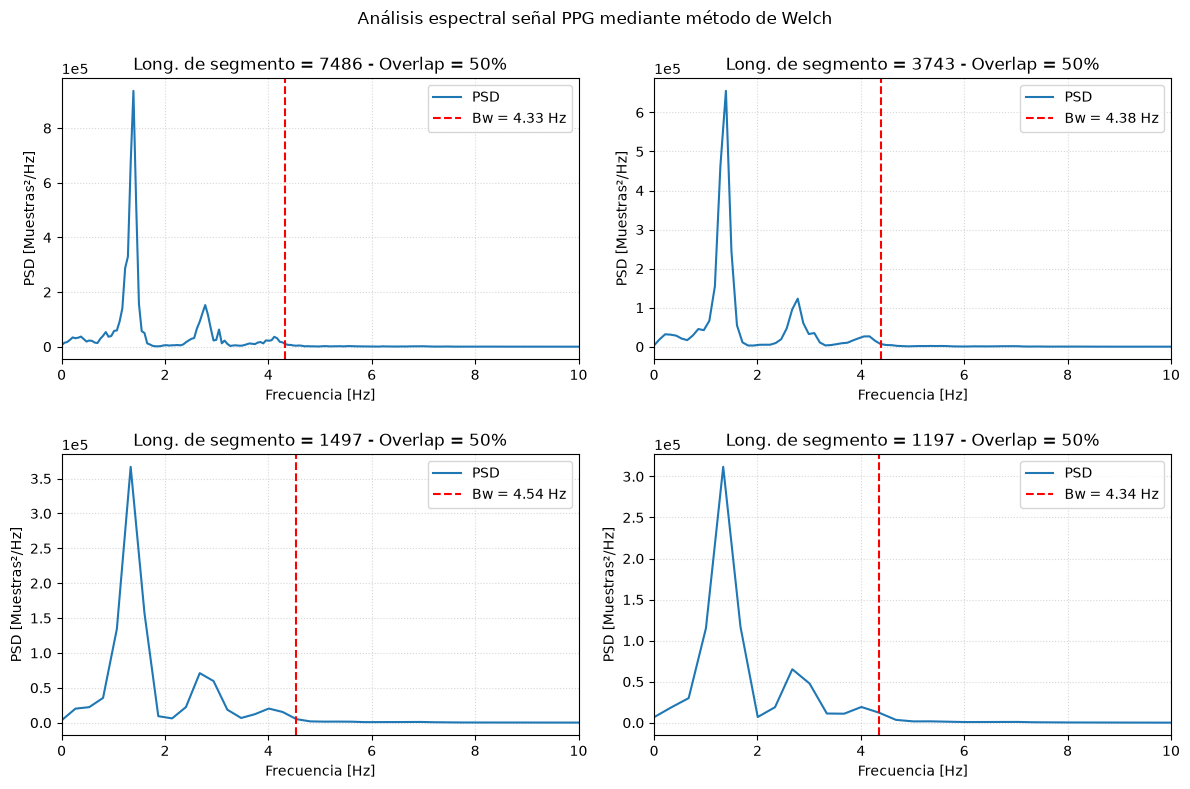

In [9]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
# import scipy.io as sio
# from scipy.io.wavfile import write

#%% --------------------------------- Definiciones
fs_ppg = 400 # Hz


#%% ------------------------- Programa

ppg = np.load('ppg_sin_ruido.npy')
len_ppg = len(ppg)
combinaciones = [
    (len_ppg//6),
    (len_ppg//12),
    (len_ppg//30),
    (len_ppg//37.5)
]

plt.close()

#%% ------------------------------ Ploteos PSD

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, (nperseg) in zip(axs.ravel(), combinaciones):

    f_ppg, psd_ppg = sig.welch(
        ppg,
        fs=fs_ppg,
        nperseg=nperseg,
        noverlap=nperseg//2,
        detrend='linear'
    )
    bw = gen.bw(f_ppg,psd_ppg,0.98) 
    if nperseg == combinaciones[1]:
        resultados_bw['ppg'] = {'f_min': 0,'f_max': bw,'BW': bw}

    ax.plot(f_ppg, psd_ppg , label='PSD')
    ax.axvline(x=bw, linestyle='--', color='red', label = f'Bw = {bw:.2f} Hz')
    ax.set_title(f'Long. de segmento = {nperseg:.0f} - Overlap = 50%')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD [Muestras²/Hz]')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlim(0, 10)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend()

plt.suptitle('Análisis espectral señal PPG mediante método de Welch')
plt.tight_layout()
plt.show()

#### Análisis de resultados: PPG

La PSD muestra un pico dominante en torno a 1.4 Hz (alrededor de 84 latidos por minuto) y dos picos más débiles cerca de 2.8 y 4.2 Hz, que corresponden al segundo y tercer armónico de la frecuencia cardíaca. Esto es esperable en una señal casi periódica y no sinusoidal. Por encima de unos 5 Hz la potencia es prácticamente nula.

Con segmentos cortos los armónicos se ensanchan y se vuelven menos nítidos, mientras que con segmentos largos se distinguen claramente. El ancho de banda resulta de **4.33, 4.38, 4.54 y 4.34 Hz**.No se ve una variación relevante debido al cambio en  `nperseg`. Se adopta **4.38 Hz** (segmentos de $N/12$), valor que incluye hasta el tercer armónico.

### Estimación espectral de potencia de señales de audio

Se analizan tres archivos de audio: *la cucaracha*, *prueba psd* y *silbido*. En todos los casos se utiliza una longitud de segmento de $N/9$ con un solapamiento del 50 %. A diferencia de las señales biomédicas, el espectro del audio no comienza necesariamente en 0 Hz, por lo que se estima la banda $[f_{min}, f_{max}]$ que contiene el 98 % central de la potencia. Ambas frecuencias de corte se indican con líneas rojas discontinuas.

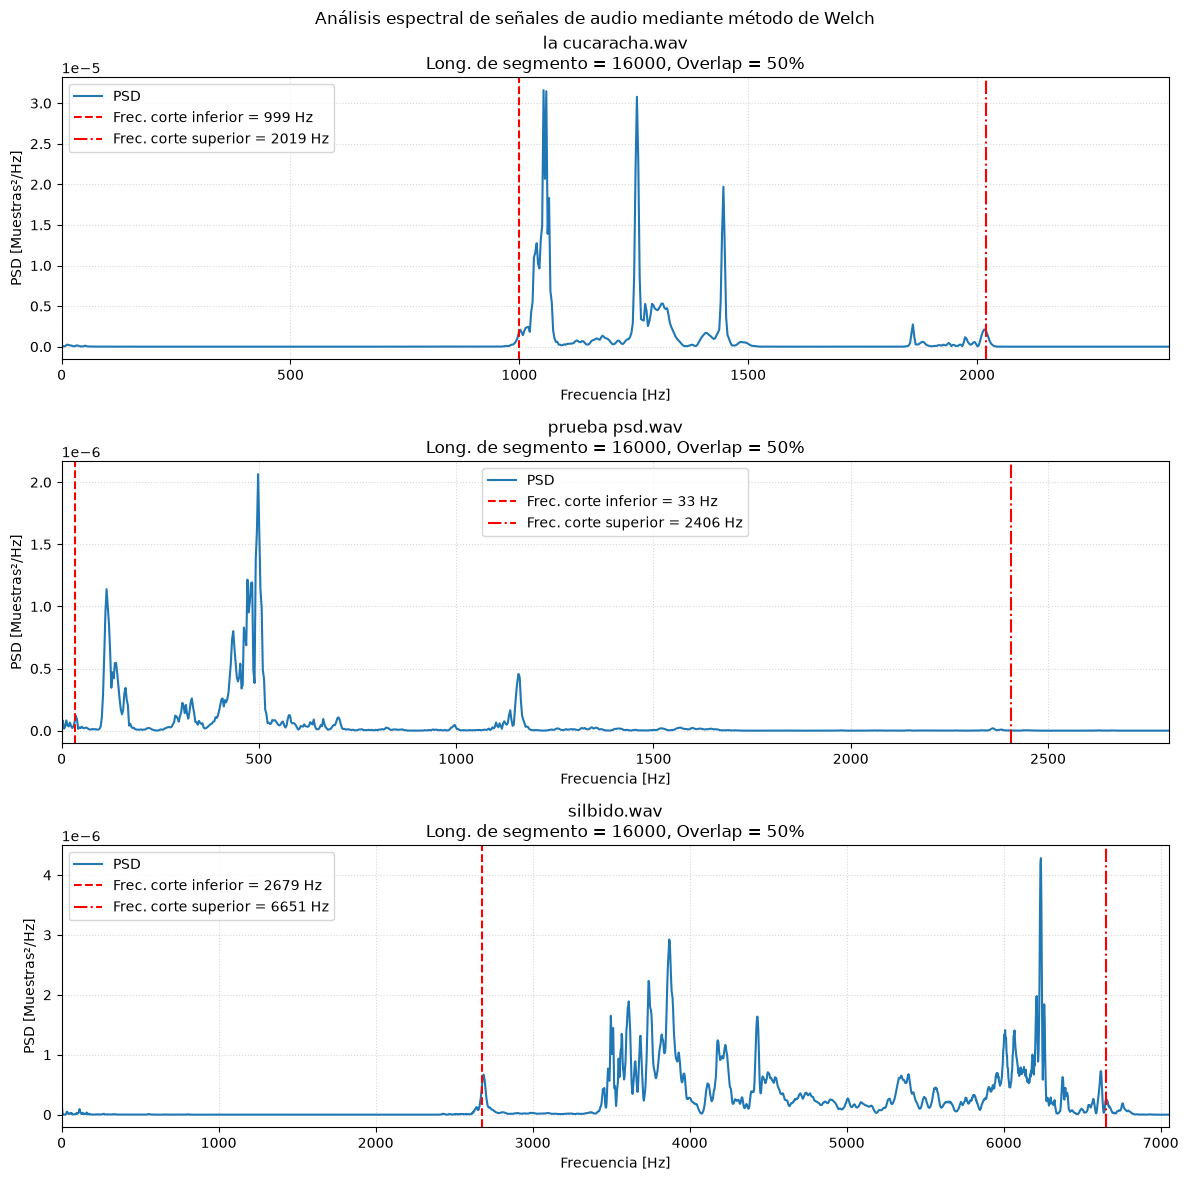

In [12]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
from scipy import signal as sig
import scipy.io as sio
import matplotlib.pyplot as plt

#%% --------------------------------- Definiciones


#%% ------------------------- Programa

plt.close()
archivos_wav = [
    'la cucaracha.wav',
    'prueba psd.wav',
    'silbido.wav'
]

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

for ax, archivo in zip(axs.ravel(), archivos_wav):
    fs_audio, wav_data = sio.wavfile.read(archivo)
    len_wav = len(wav_data)
    nperseg = int(len_wav // 9)
    f_wav, psd_wav = sig.welch(
        wav_data,
        fs=fs_audio,
        nperseg=nperseg,
        noverlap=nperseg//2,
        detrend='linear'
    )
    f_min , f_max , bw = gen.bw_media(f_wav, psd_wav, 0.98)
    resultados_bw[archivo] = {'f_min': f_min,'f_max': f_max,'BW': bw}
    ax.plot(f_wav, psd_wav, label='PSD')
    ax.axvline(x=f_min,linestyle='--',color='red',label=f'Frec. corte inferior = {f_min:.0f} Hz')
    ax.axvline(x=f_max,linestyle='-.',color='red',label=f'Frec. corte superior = {f_max:.0f} Hz')
    ax.set_title(f'{archivo}\n'f'Long. de segmento = {nperseg}, Overlap = 50%')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD [Muestras²/Hz]')
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0, 0))
    ax.set_xlim(0, f_max + 400)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend()

plt.suptitle('Análisis espectral de señales de audio mediante método de Welch')
plt.tight_layout()
plt.show()

#### Análisis de resultados: audio

- **la cucaracha:** la potencia se concentra en unos pocos picos bien definidos, cerca de 1050, 1260 y 1450 Hz. La banda del 98 % va de 999 a 2019 Hz (**BW = 1020 Hz**).
- **prueba psd:** el espectro tiene un pico principal cerca de 500 Hz, otro cerca de 110 Hz y uno menor alrededor de 1150 Hz. La banda es de 33 a 2406 Hz (**BW = 2373 Hz**). La mayor parte de la energía está por debajo de 1200 Hz, y la frecuencia máxima queda alta por la presencia de componentes débiles cerca de 2350 Hz.
- **silbido:** la energía se ubica en frecuencias altas, principalmente entre 3500 y 6500 Hz, con un pico intenso cerca de 6200 Hz. La banda va de 2679 a 6651 Hz (**BW = 3972 Hz**), la más ancha de las tres y además la que está más desplazada hacia frecuencias altas.

En los tres casos la PSD presenta muchos picos finos porque se usan segmentos largos ($N/9$), que dan buena resolución a costa de una mayor varianza.

---

## 2. Estimación del ancho de banda (tabla)

La siguiente tabla resume las frecuencias mínima y máxima y el ancho de banda de cada señal. Para el ECG y la PPG se informa el valor obtenido con segmentos de longitud $N/12$, y la frecuencia mínima es 0 Hz por definición, ya que el ancho de banda se mide desde continua. Para el audio, las frecuencias mínima y máxima surgen directamente del criterio del 98 % central.

In [11]:
from IPython.display import display, HTML
def mostrar_tabla_bw():

    estilo_th = """
        border: 1px solid #dddddd;
        text-align: center;
        padding: 8px;
        background-color: #f2f2f2;
    """

    estilo_td = """
        border: 1px solid #dddddd;
        text-align: center;
        padding: 8px;
    """

    html = f"""
    <h3 style='text-align: center;'>Ancho de banda de las señales</h3>

    <table style='border-collapse: collapse; width: 100%;'>
        <tr>
            <th style='{estilo_th}'>Señal</th>
            <th style='{estilo_th}'>Frecuencia mínima [Hz]</th>
            <th style='{estilo_th}'>Frecuencia máxima [Hz]</th>
            <th style='{estilo_th}'>Ancho de banda [Hz]</th>
        </tr>
    """

    for nombre, datos in resultados_bw.items():

        html += f"""
        <tr>
            <td style='{estilo_td}'>{nombre}</td>
            <td style='{estilo_td}'>{datos['f_min']:.2f}</td>
            <td style='{estilo_td}'>{datos['f_max']:.2f}</td>
            <td style='{estilo_td}'>{datos['BW']:.2f}</td>
        </tr>
        """

    html += "</table>"

    display(HTML(html))
mostrar_tabla_bw()



Señal,Frecuencia mínima [Hz],Frecuencia máxima [Hz],Ancho de banda [Hz]
ecg,0.00,27.60,27.60
ppg,0.00,4.38,4.38
la cucaracha.wav,999.00,2019.00,1020.00
prueba psd.wav,33.00,2406.00,2373.00
silbido.wav,2679.00,6651.00,3972.00


---

## Conclusión

- **Señales biomédicas.** El ECG tiene un ancho de banda de aproximadamente **27.6 Hz** y la PPG de **4.38 Hz**. En ambos casos la potencia se concentra en las frecuencias más bajas, y la diferencia entre ellos (alrededor de seis veces) se explica por la forma de onda: el ECG contiene transiciones rápidas que aportan energía hasta decenas de hertz, mientras que el pulso de la PPG es mucho más suave.
- **Audio.** Los anchos de banda son considerablemente mayores y dependen de la naturaleza de cada registro: **1020 Hz** para *la cucaracha* (999 a 2019 Hz), **2373 Hz** para *prueba psd* (33 a 2406 Hz) y **3972 Hz** para *silbido* (2679 a 6651 Hz). Las señales de audio no parten de 0 Hz, por lo que la frecuencia mínima también es un dato relevante.
- **Efecto de `nperseg`.** La longitud del segmento modifica notablemente el aspecto de la PSD (más ruidosa con segmentos largos, más suave pero menos resolutiva con segmentos cortos), pero el ancho de banda estimado casi no cambia: entre 27.0 y 27.8 Hz para el ECG y entre 4.33 y 4.54 Hz para la PPG. Las pequeñas variaciones son del orden de la resolución en frecuencia.
- **Dependencia del criterio.** El valor obtenido depende del porcentaje de potencia elegido (98 %). En señales con colas de muy baja potencia, como *prueba psd*, unos pocos picos pequeños a frecuencias altas pueden extender la frecuencia máxima bastante más allá de donde se observa la mayor parte de la energía.